In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [43]:
df = pd.read_csv(r"D:\E Drive\Sentiflow-Network Intrusion Detection\Data\Network_anomaly_data.csv")
df

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [44]:
print("shape",df.shape)

shape (125973, 43)


In [45]:
df.select_dtypes(include=["int64"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   duration          125973 non-null  int64
 1   srcbytes          125973 non-null  int64
 2   dstbytes          125973 non-null  int64
 3   land              125973 non-null  int64
 4   wrongfragment     125973 non-null  int64
 5   urgent            125973 non-null  int64
 6   hot               125973 non-null  int64
 7   numfailedlogins   125973 non-null  int64
 8   loggedin          125973 non-null  int64
 9   numcompromised    125973 non-null  int64
 10  rootshell         125973 non-null  int64
 11  suattempted       125973 non-null  int64
 12  numroot           125973 non-null  int64
 13  numfilecreations  125973 non-null  int64
 14  numshells         125973 non-null  int64
 15  numaccessfiles    125973 non-null  int64
 16  numoutboundcmds   125973 non-null  int64
 17  ishostlogi

In [46]:
df.select_dtypes(include=["float"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   serrorrate              125973 non-null  float64
 1   srvserrorrate           125973 non-null  float64
 2   rerrorrate              125973 non-null  float64
 3   srvrerrorrate           125973 non-null  float64
 4   samesrvrate             125973 non-null  float64
 5   diffsrvrate             125973 non-null  float64
 6   srvdiffhostrate         125973 non-null  float64
 7   dsthostsamesrvrate      125973 non-null  float64
 8   dsthostdiffsrvrate      125973 non-null  float64
 9   dsthostsamesrcportrate  125973 non-null  float64
 10  dsthostsrvdiffhostrate  125973 non-null  float64
 11  dsthostserrorrate       125973 non-null  float64
 12  dsthostsrvserrorrate    125973 non-null  float64
 13  dsthostrerrorrate       125973 non-null  float64
 14  dsthostsrvrerrorrate

In [53]:
df.select_dtypes(include=["object"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   protocoltype     125973 non-null  object
 1   service          125973 non-null  object
 2   flag             125973 non-null  object
 3   attack           125973 non-null  object
 4   attack_category  125973 non-null  object
 5   binary_target    125973 non-null  object
dtypes: object(6)
memory usage: 5.8+ MB


In [54]:
for i in df.select_dtypes(include=['object']).columns:
   print(df[i].value_counts())

protocoltype
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64
attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule            

In [55]:
# Dictionary mapping each attack to its category
attack_mapping = {
    # Normal
    'normal': 'Normal',

    # DoS
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',

    # Probe
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',

    # R2L
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R'
}

# Apply mapping
df['attack_category'] = df['attack'].map(attack_mapping)

# Check if any attack labels were not mapped
print(df[df['attack_category'].isna()]['attack'].unique())

# Count the new categories
print(df['attack_category'].value_counts())

[]
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [56]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target'],
      dtype='object')

In [57]:
#Creating Binary Category
df['binary_target'] = df['attack_category'].apply(
    lambda x: 'Normal' if x == 'Normal' else 'Attack'
)

print(df['binary_target'].value_counts())

binary_target
Normal    67343
Attack    58630
Name: count, dtype: int64


In [58]:
print("# Unique values of Numerical Values")
catagorical_Numeric_cols=list()
for i in df.select_dtypes(include=["int64"]).columns:
    print(i , df[i].nunique())
    if df[i].nunique() <= 10:
        catagorical_Numeric_cols.append(i)

# Unique values of Numerical Values
duration 2981
srcbytes 3341
dstbytes 9326
land 2
wrongfragment 3
urgent 4
hot 28
numfailedlogins 6
loggedin 2
numcompromised 88
rootshell 2
suattempted 3
numroot 82
numfilecreations 35
numshells 3
numaccessfiles 10
numoutboundcmds 1
ishostlogin 2
isguestlogin 2
count 512
srvcount 509
dsthostcount 256
dsthostsrvcount 256
lastflag 22


Droping the 'numoutboundcmds' as it has been constant throughout the Data.

In [ ]:

df.drop('numoutboundcmds',axis=1,inplace=True)

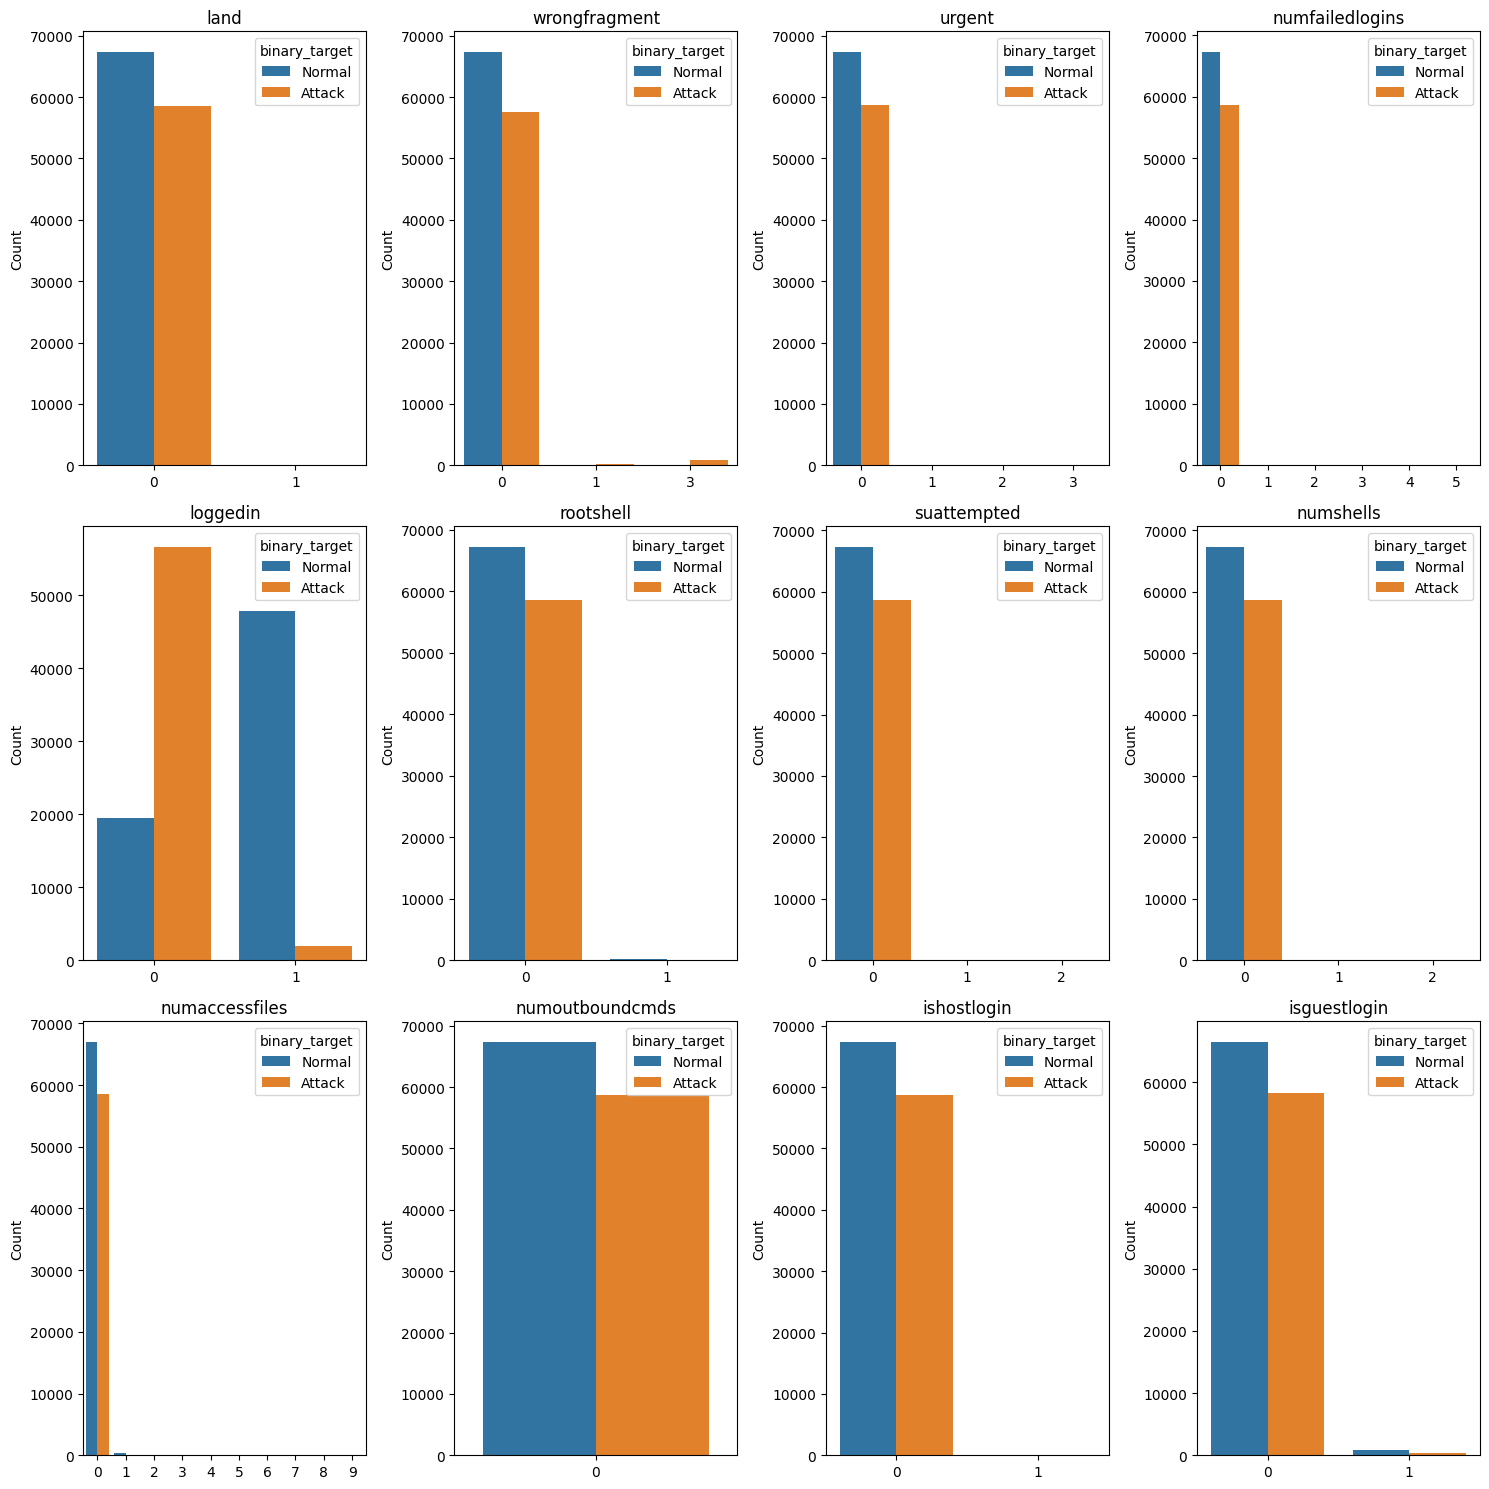

In [60]:
import math
cols = catagorical_Numeric_cols

n_cols = 4                              # Number of plots per row
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(15, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        hue='binary_target',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [62]:
print("#Unique values of Numerical Values")
for i in df.select_dtypes(include=["float64"]).columns:
    print(i , df[i].nunique())

#Unique values of Numerical Values
serrorrate 89
srvserrorrate 86
rerrorrate 82
srvrerrorrate 62
samesrvrate 101
diffsrvrate 95
srvdiffhostrate 60
dsthostsamesrvrate 101
dsthostdiffsrvrate 101
dsthostsamesrcportrate 101
dsthostsrvdiffhostrate 75
dsthostserrorrate 101
dsthostsrvserrorrate 100
dsthostrerrorrate 101
dsthostsrvrerrorrate 101


In [63]:
print("#Unique values of Categorical Values")
for i in df.select_dtypes(include=["object"]).columns:
    print(i , df[i].nunique())

#Unique values of Categorical Values
protocoltype 3
service 70
flag 11
attack 23
attack_category 5
binary_target 2


## Univariate Analysis and Bivariate Analysis

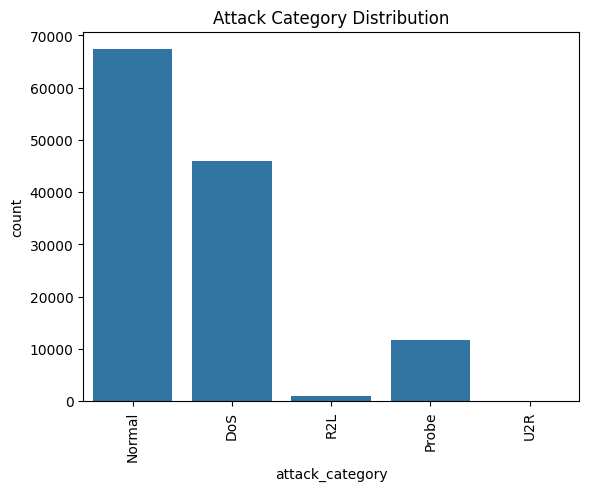

In [24]:
sns.countplot(x=df['attack_category'])
plt.title("Attack Category Distribution")
plt.xticks(rotation=90)
plt.show()

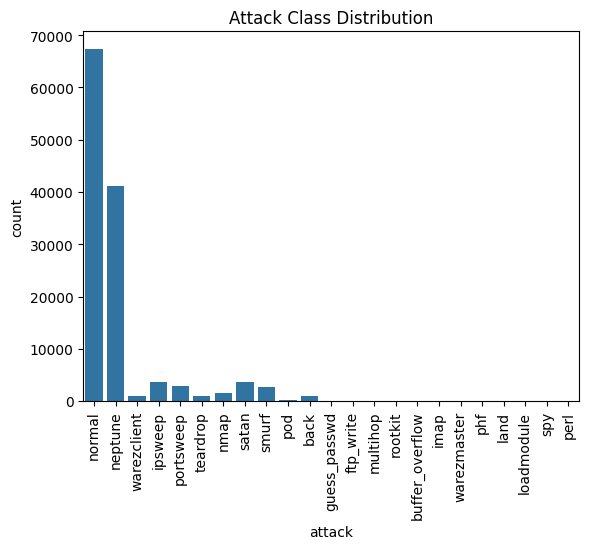

In [64]:
sns.countplot(x=df['attack'])
plt.title("Attack Class Distribution")
plt.xticks(rotation=90)
plt.show()

In [66]:
df.select_dtypes(include="float64").columns
df.select_dtypes(include='int64').columns

Index(['duration', 'srcbytes', 'dstbytes', 'land', 'wrongfragment', 'urgent',
       'hot', 'numfailedlogins', 'loggedin', 'numcompromised', 'rootshell',
       'suattempted', 'numroot', 'numfilecreations', 'numshells',
       'numaccessfiles', 'numoutboundcmds', 'ishostlogin', 'isguestlogin',
       'count', 'srvcount', 'dsthostcount', 'dsthostsrvcount', 'lastflag'],
      dtype='object')

# Numerical Distribution

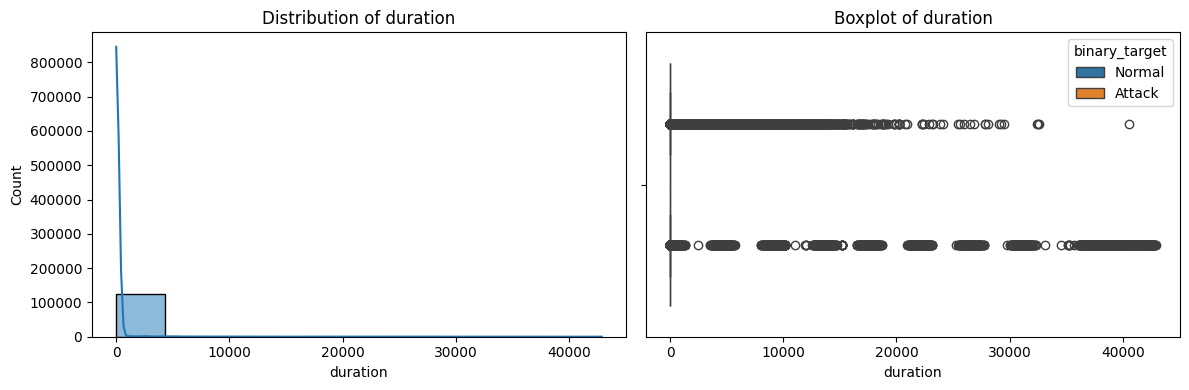

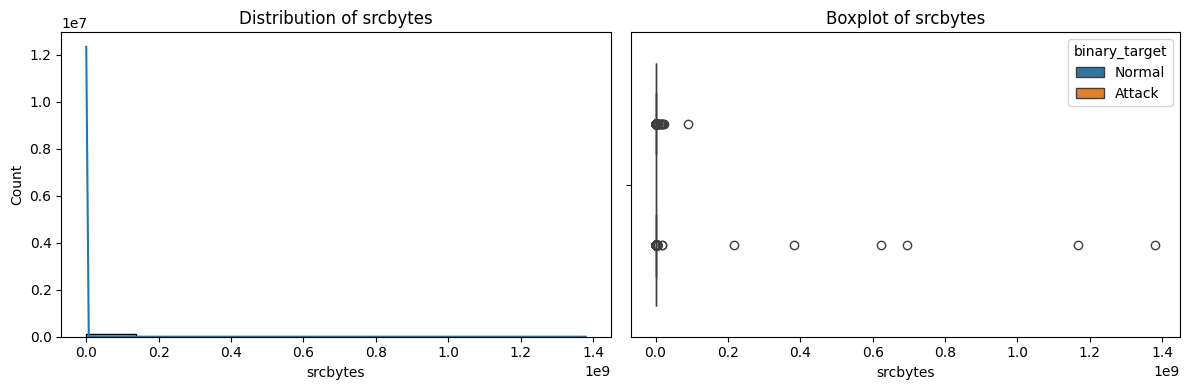

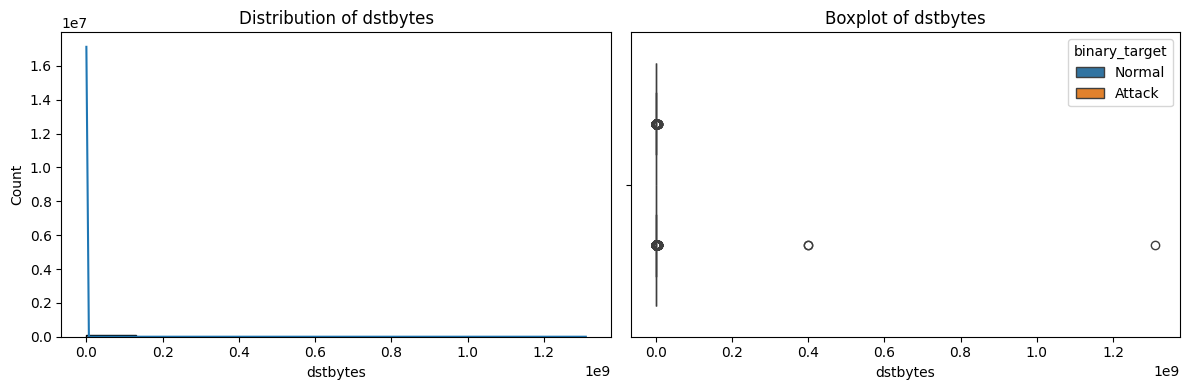

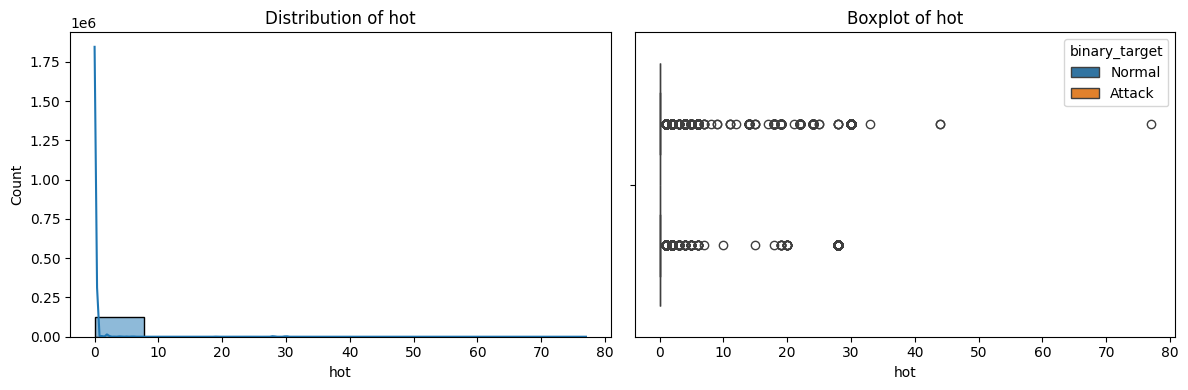

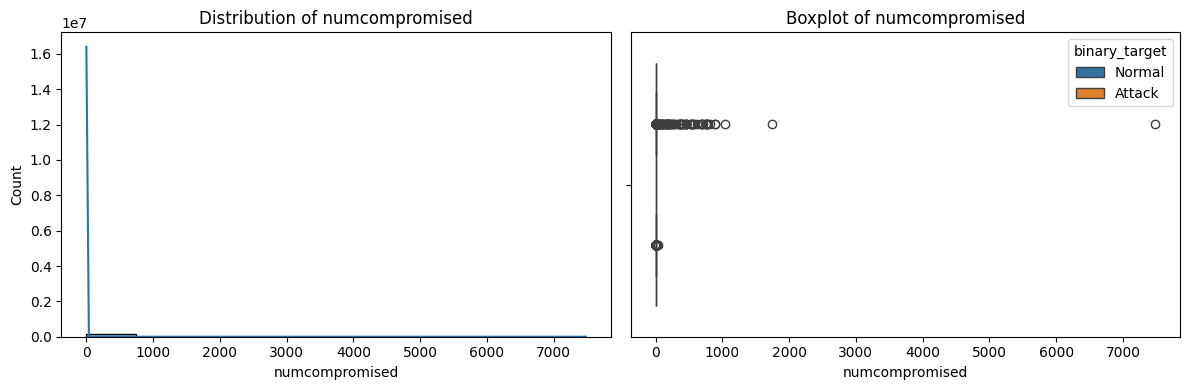

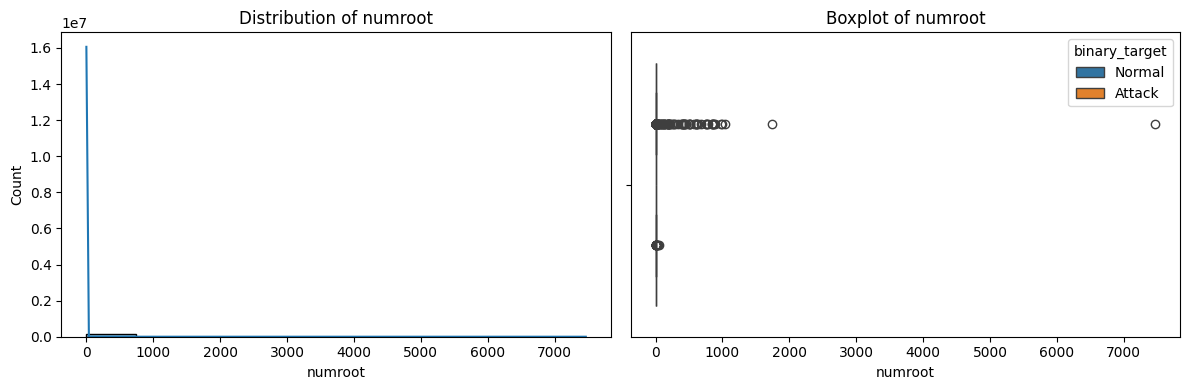

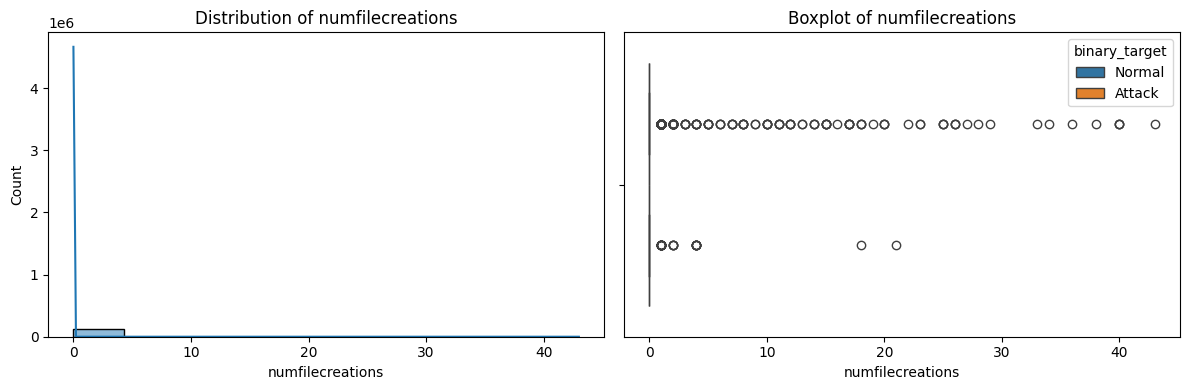

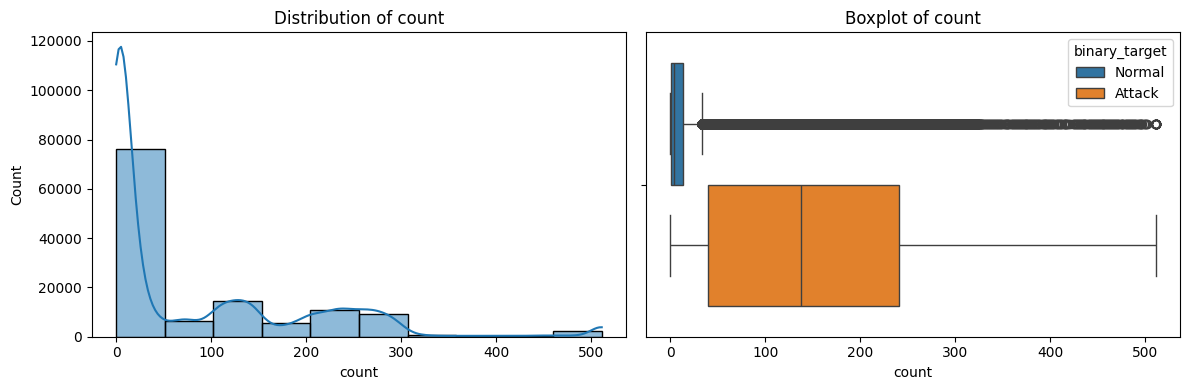

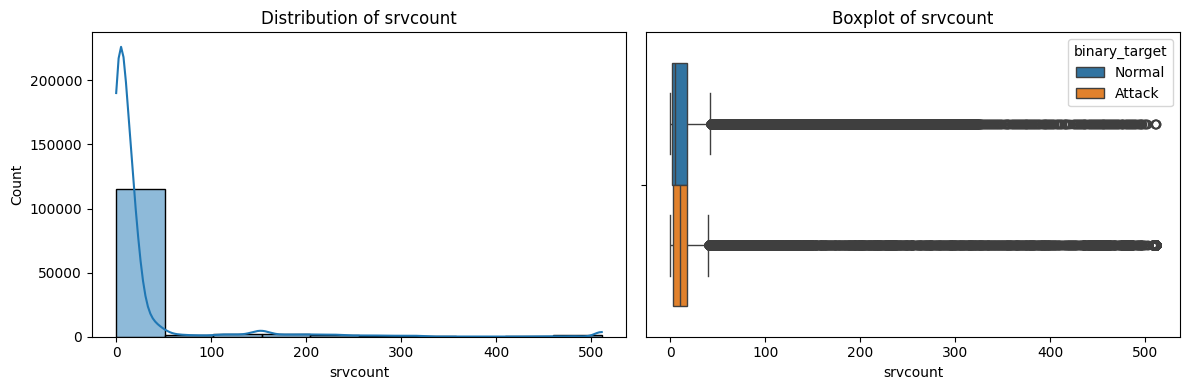

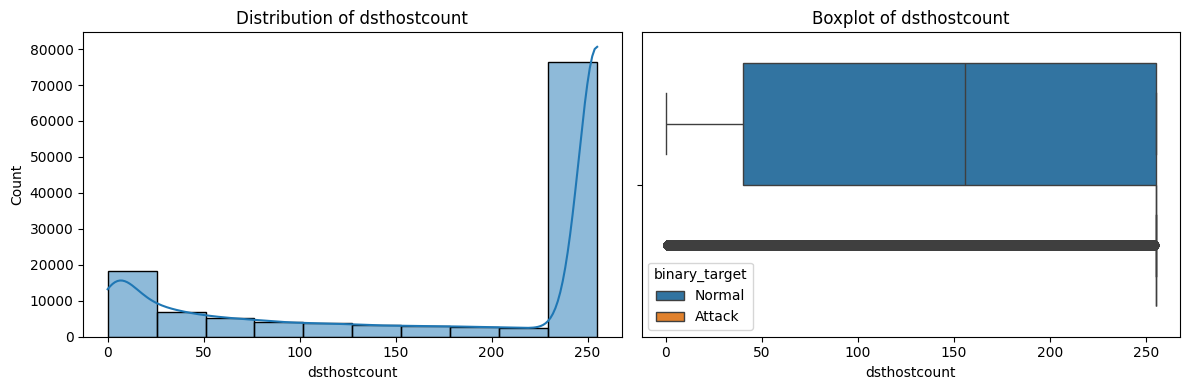

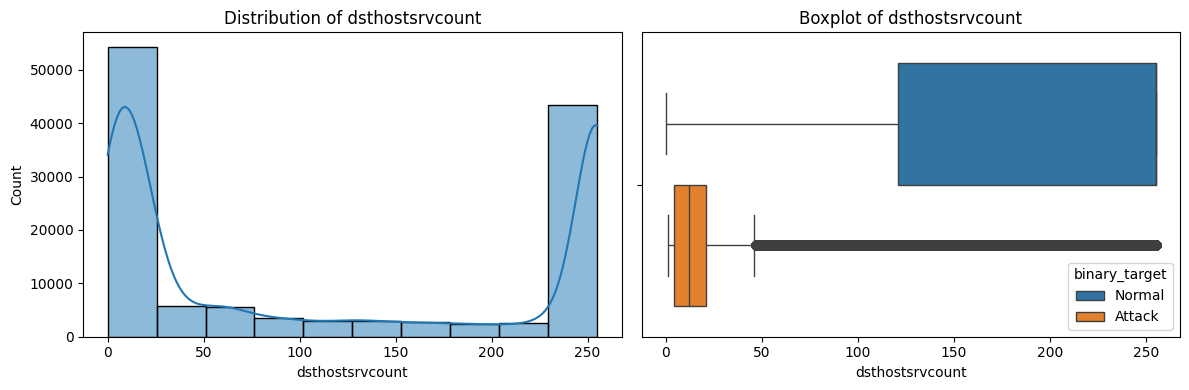

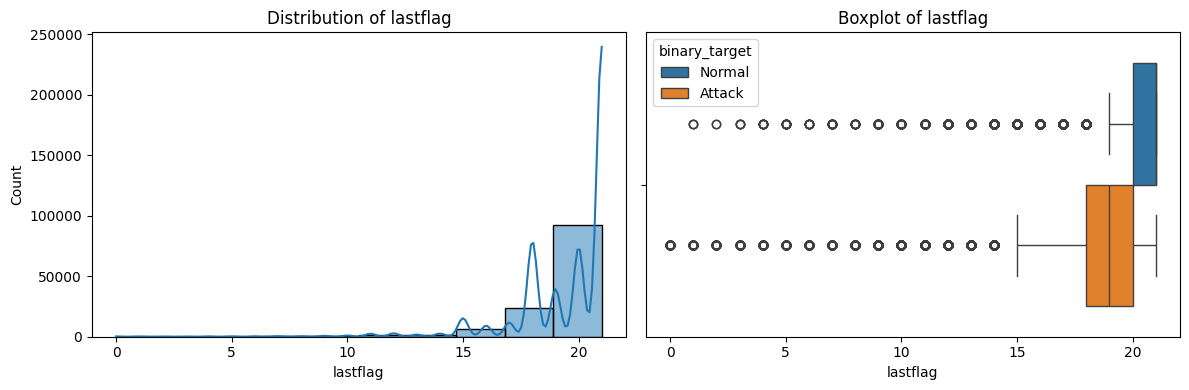

In [73]:
# Distribution of Numerical Features

num_cols = df.select_dtypes(include="int64").columns

for col in num_cols:
    if col not in catagorical_Numeric_cols:
        
       plt.figure(figsize=(12,4))
   
       plt.subplot(1,2,1)
       sns.histplot(df[col],kde=True,bins=10)
       plt.title(f"Distribution of {col}")
   
       plt.subplot(1,2,2)
       sns.boxplot(x=df[col],hue=df['binary_target'])
       plt.title(f"Boxplot of {col}")
   
       plt.tight_layout()
       plt.show()
    


# Numerical Distribution

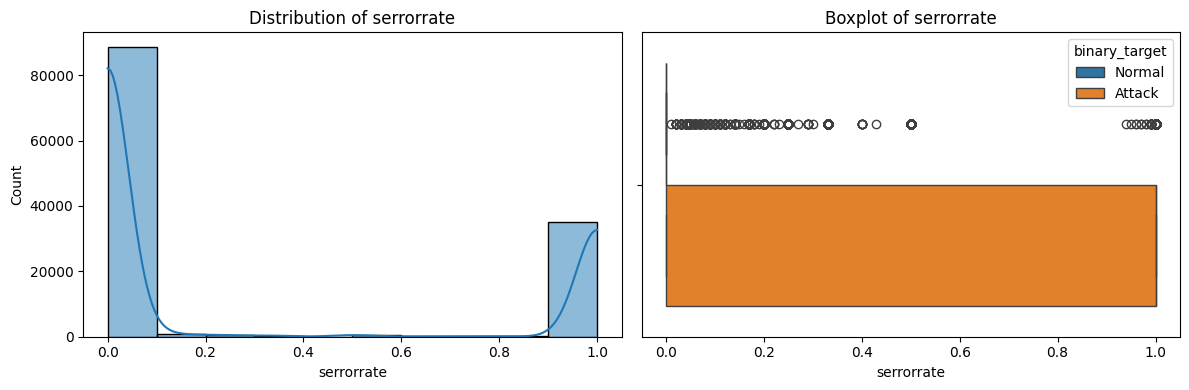

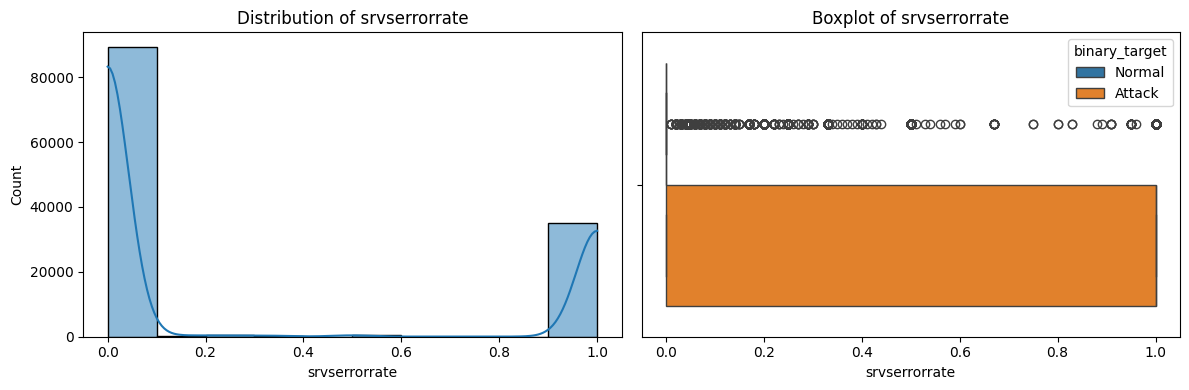

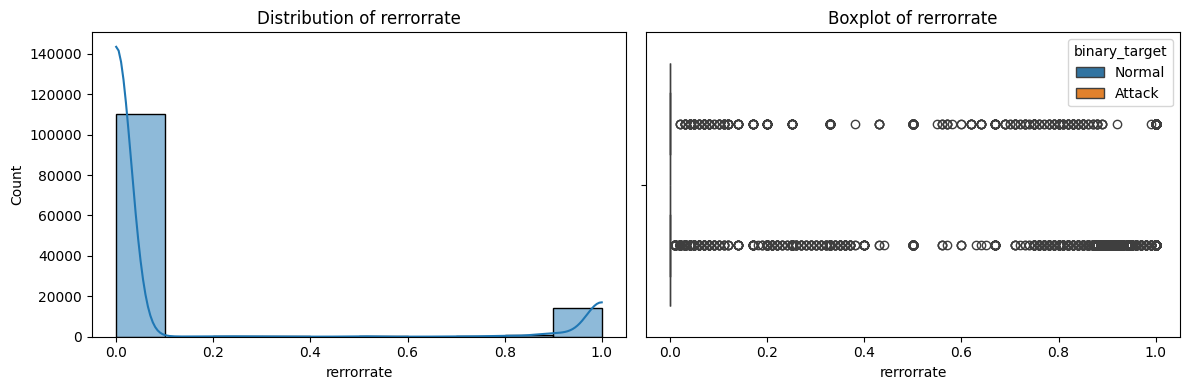

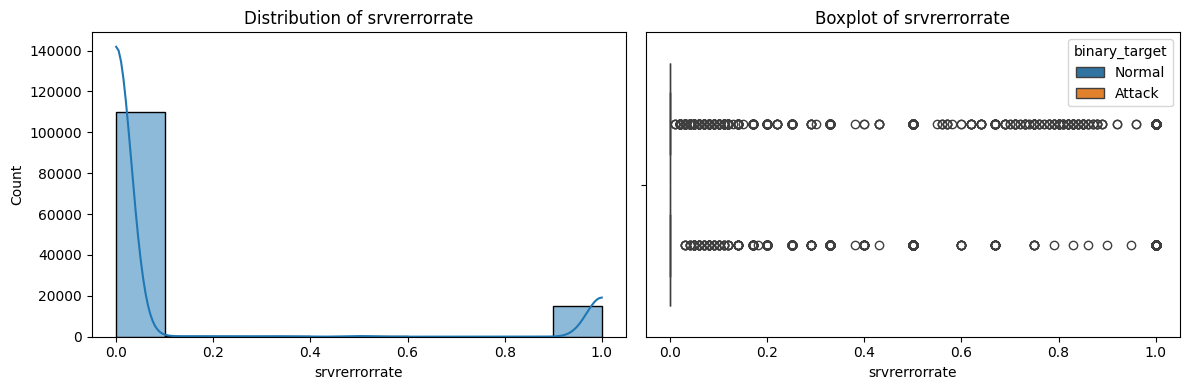

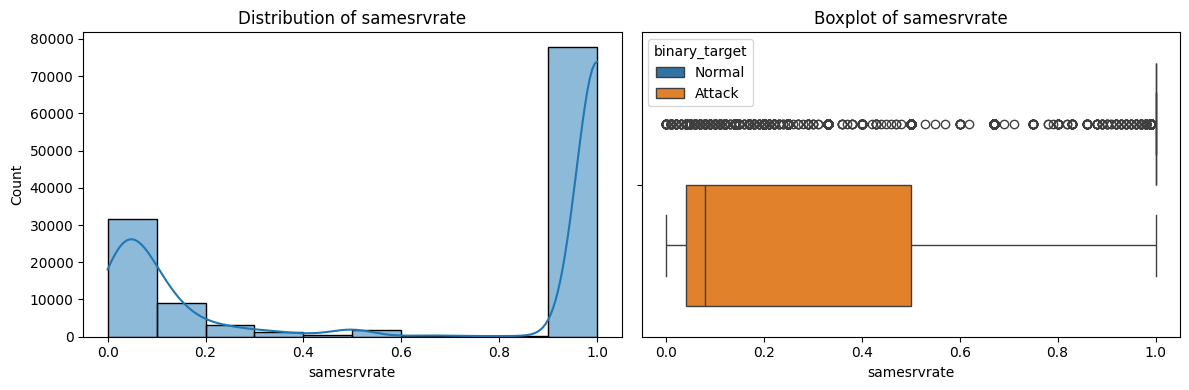

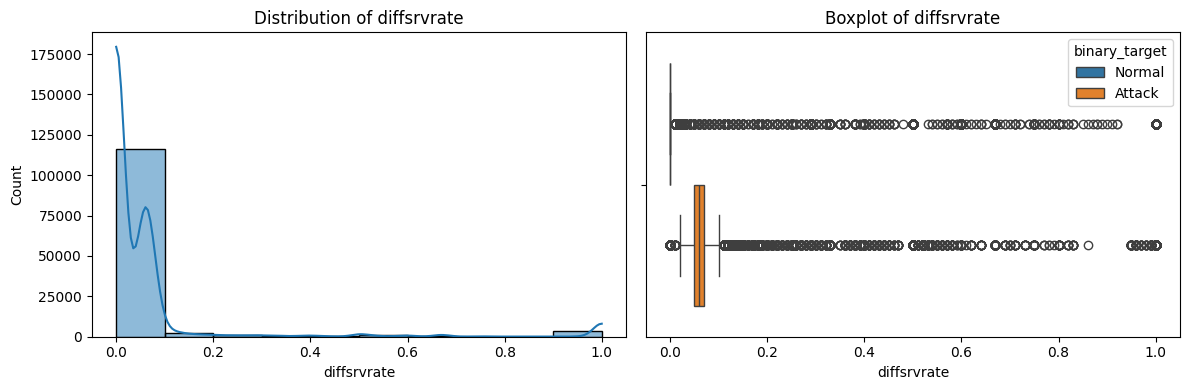

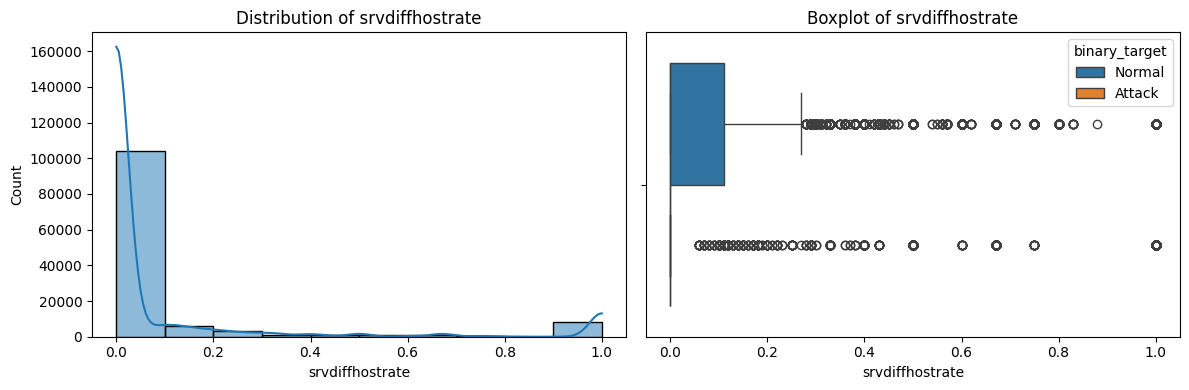

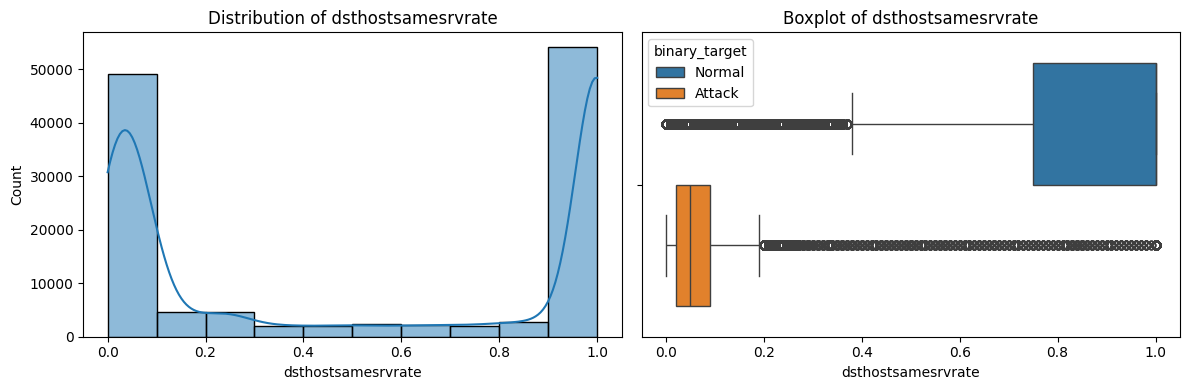

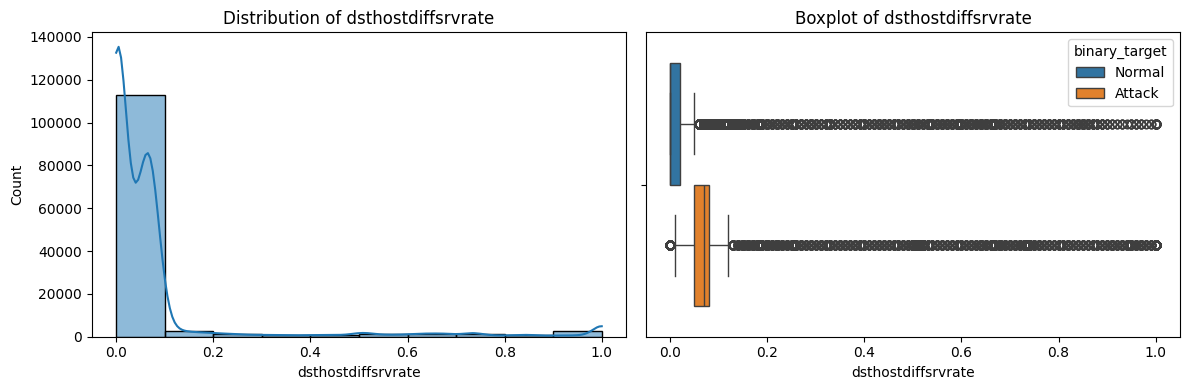

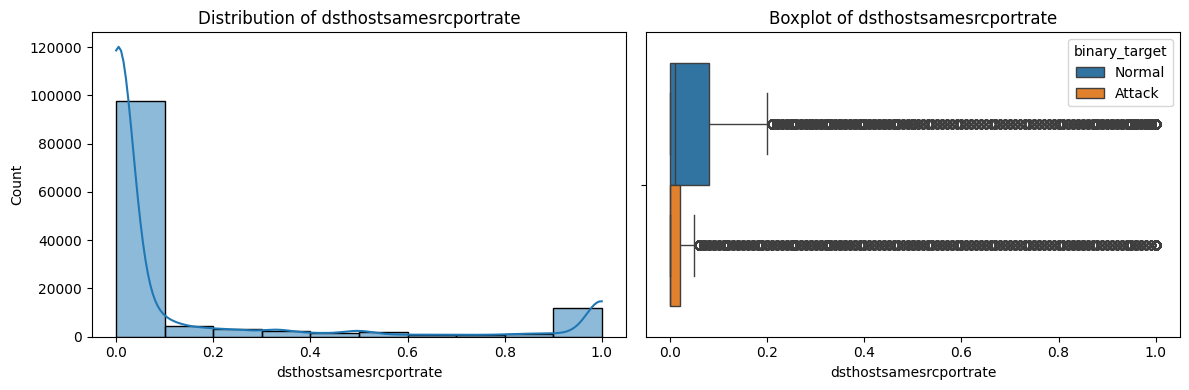

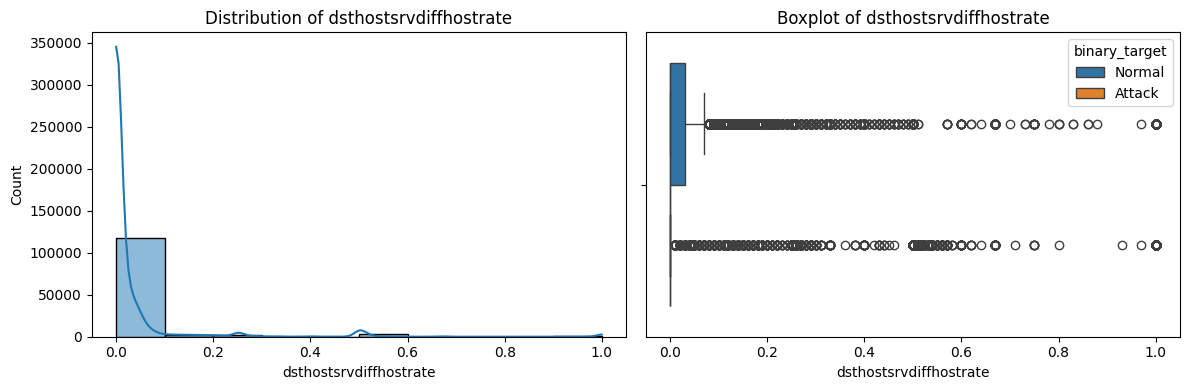

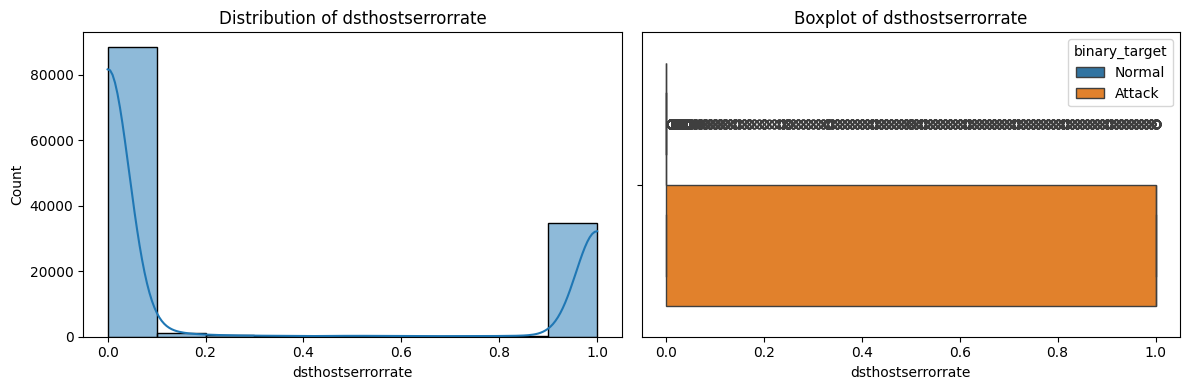

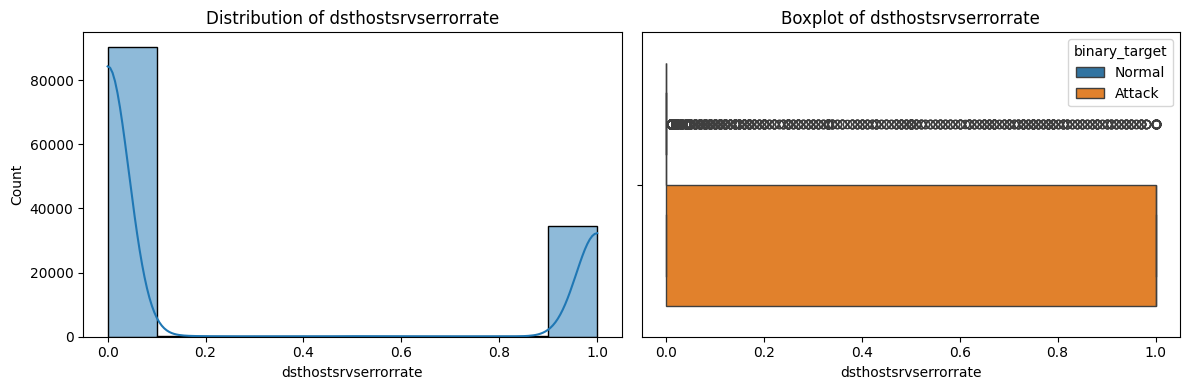

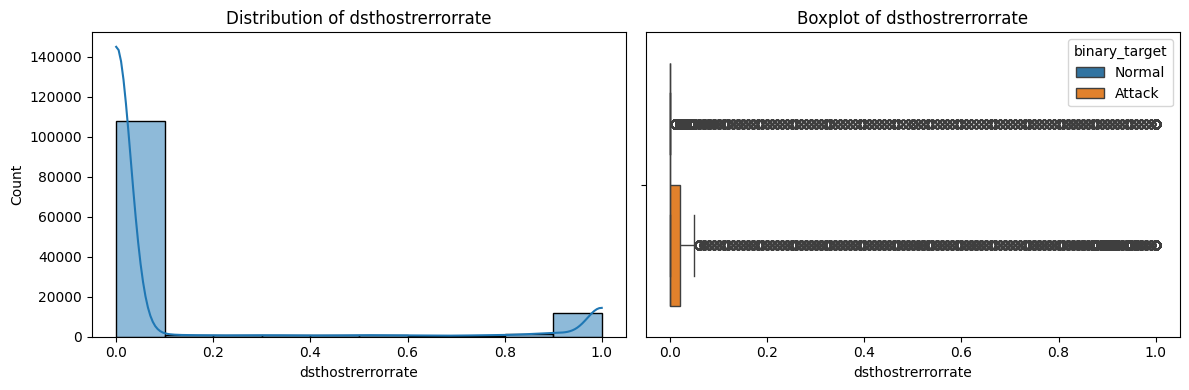

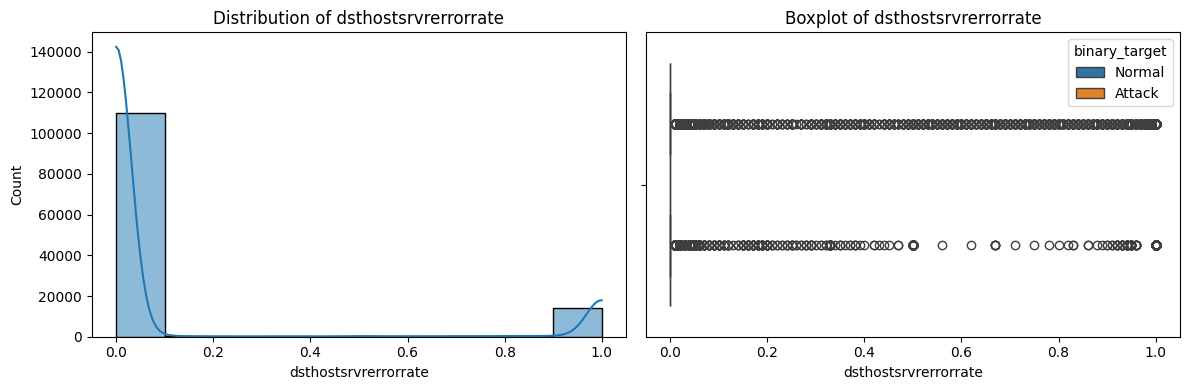

In [72]:
# Numerical Feature Distribution
num_cols = df.select_dtypes(include="float64").columns

for col in num_cols:
        
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True,bins=10)
    plt.title(f"Distribution of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col],hue=df['binary_target'])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()
    

# Categorical Feature Distribution


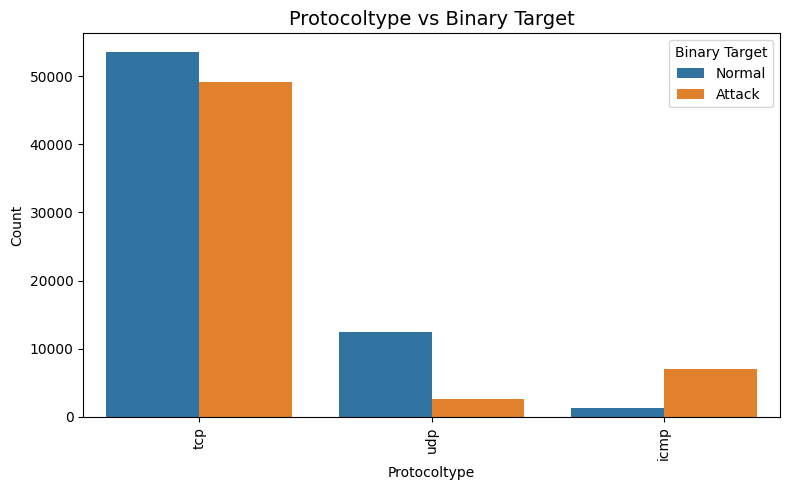

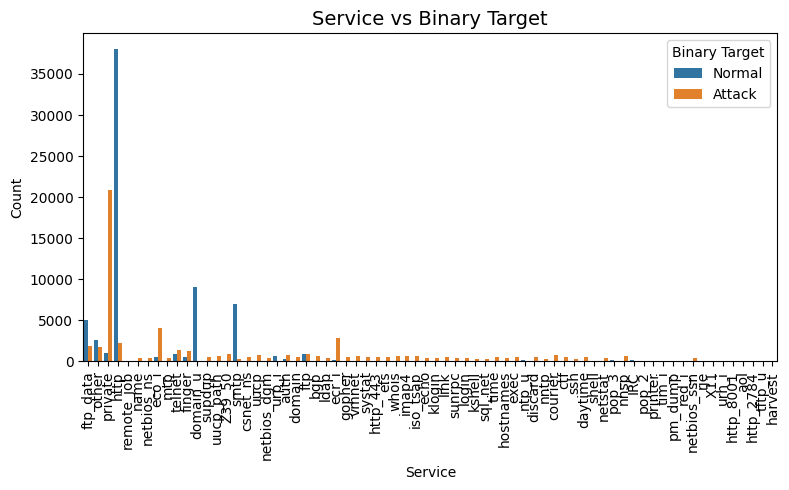

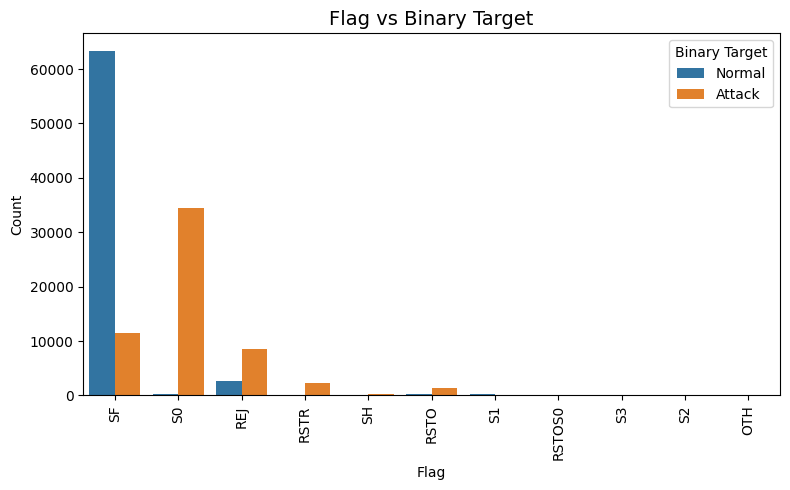

In [82]:
# Protocol Type
categorical_cols = [
    'protocoltype',
    'service',
    'flag'
]

for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue='binary_target'
    )

    plt.title(f'{col.replace("_", " ").title()} vs Binary Target', fontsize=14)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.legend(title='Binary Target')
    plt.tight_layout()
    plt.show()

In [88]:
numeric_features=df.select_dtypes(include=['int64','float64']).columns
print(df[numeric_features].skew())

duration                   11.880230
srcbytes                  190.669347
dstbytes                  290.052911
land                       70.965063
wrongfragment              11.457988
urgent                    149.914509
hot                        12.589886
numfailedlogins            53.764424
loggedin                    0.426437
numcompromised            250.107883
rootshell                  27.247411
suattempted                42.435591
numroot                   236.913724
numfilecreations           55.665341
numshells                  59.592151
numaccessfiles             45.554961
numoutboundcmds             0.000000
ishostlogin               354.926753
isguestlogin               10.155746
count                       1.514275
srvcount                    4.694162
serrorrate                  0.963201
srvserrorrate               0.970597
rerrorrate                  2.325532
srvrerrorrate               2.327033
samesrvrate                -0.572499
diffsrvrate                 4.379815
s

In [89]:
print(df[numeric_features].kurt())

duration                     156.076810
srcbytes                   39354.121255
dstbytes                   90941.734526
land                        5034.120053
wrongfragment                130.829766
urgent                     24967.319945
hot                          168.014265
numfailedlogins             3869.069296
loggedin                      -1.818180
numcompromised             75956.227694
rootshell                    740.433146
suattempted                 1835.631728
numroot                    70070.208760
numfilecreations            3603.311713
numshells                   3993.592804
numaccessfiles              2862.804357
numoutboundcmds                0.000000
ishostlogin               125973.000000
isguestlogin                 101.140786
count                          2.006917
srvcount                      24.244484
serrorrate                    -1.054604
srvserrorrate                 -1.044294
rerrorrate                     3.445847
srvrerrorrate                  3.445834


## Correleation Analysis

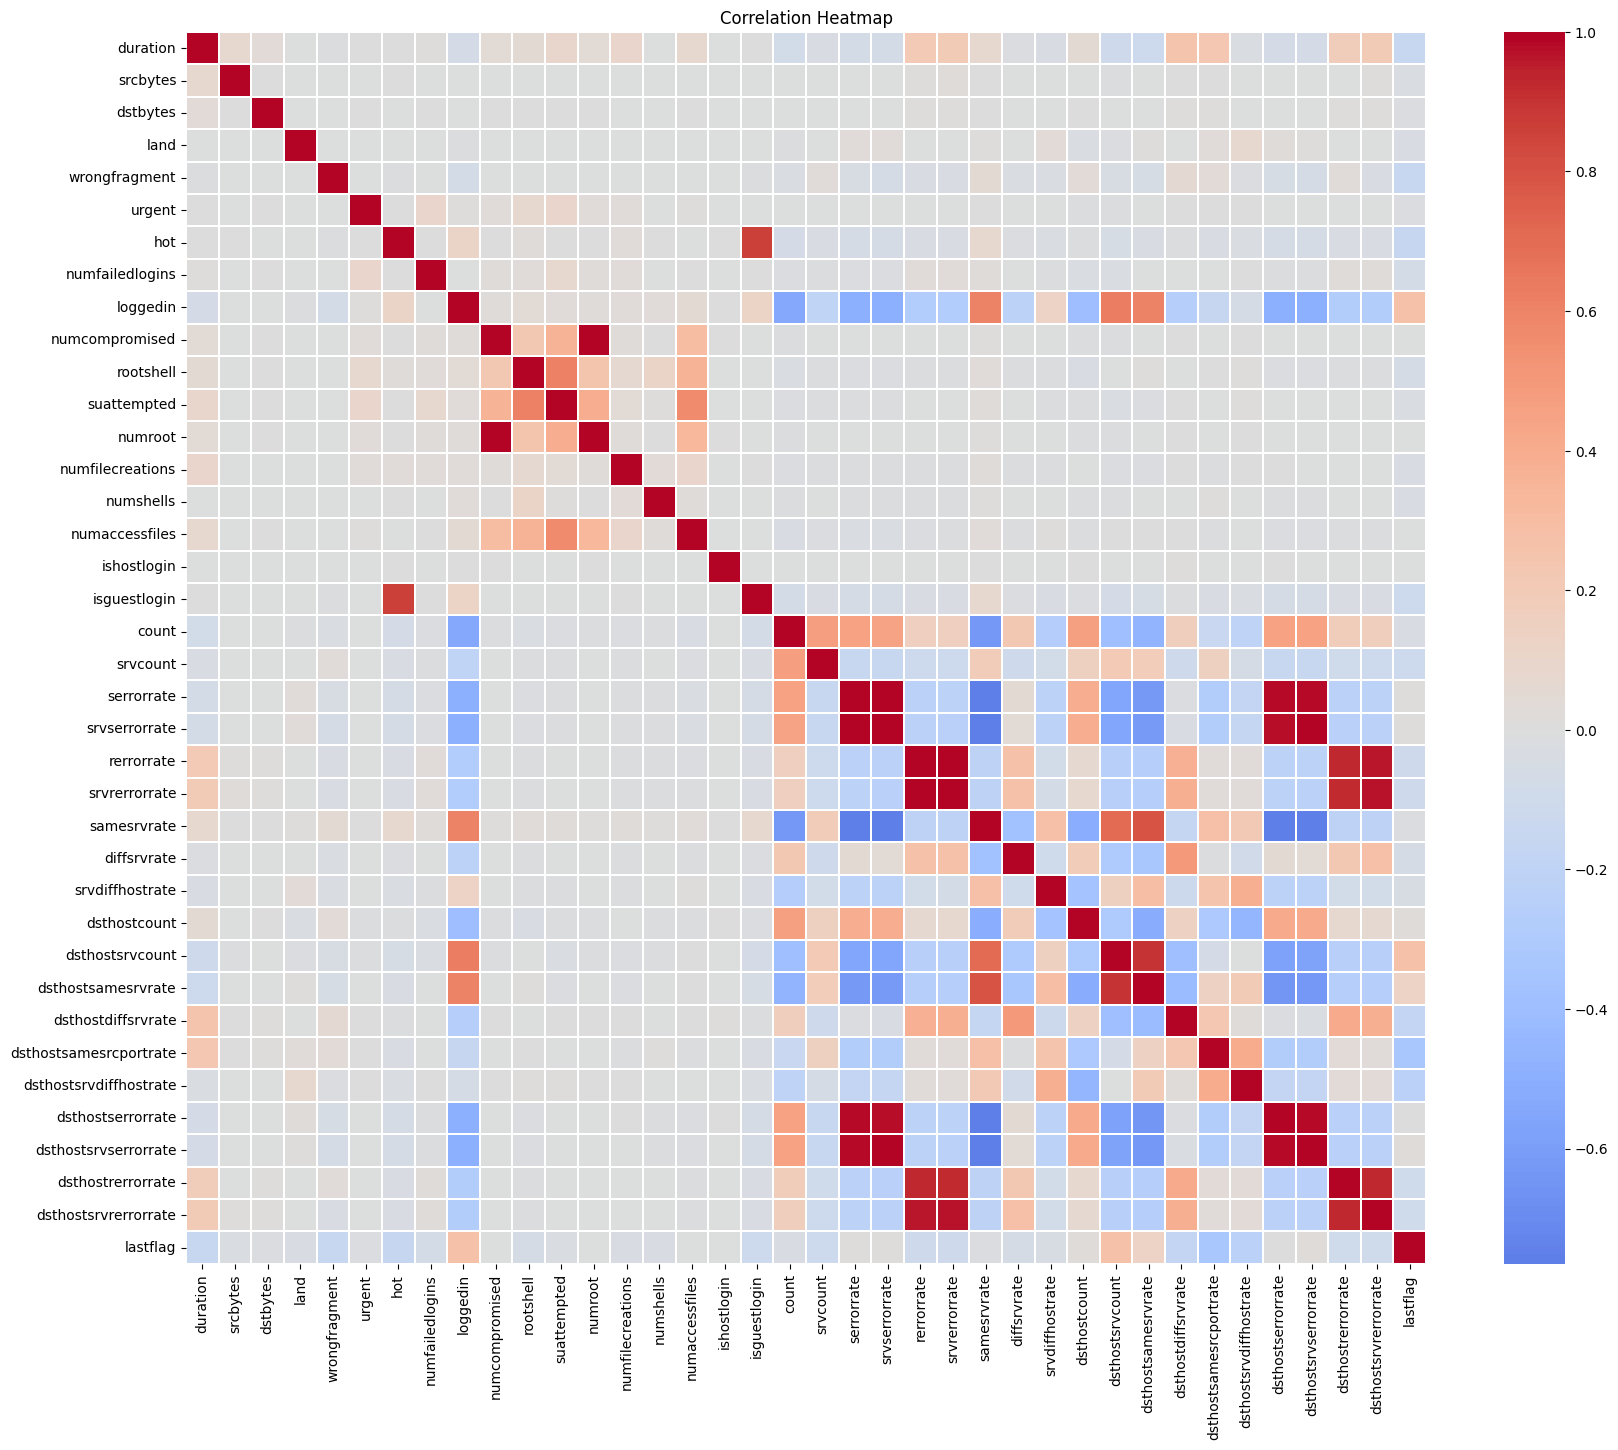

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,16))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            linewidths=0.2)

plt.title("Correlation Heatmap")
plt.show()


In [31]:
## Higly correlated Features
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

high_corr = [(col,row,upper.loc[row,col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row,col] > 0.85]

high_corr = pd.DataFrame(high_corr,
                         columns=['Feature 1','Feature 2','Correlation'])

high_corr.sort_values("Correlation",ascending=False)

,Feature 1,Feature 2,Correlation
0,numroot,numcompromised,0.998833
2,srvserrorrate,serrorrate,0.993289
3,srvrerrorrate,rerrorrate,0.989008
8,dsthostsrvserrorrate,srvserrorrate,0.986252
9,dsthostsrvserrorrate,dsthostserrorrate,0.985052
7,dsthostsrvserrorrate,serrorrate,0.981139
5,dsthostserrorrate,serrorrate,0.979373
6,dsthostserrorrate,srvserrorrate,0.977596
13,dsthostsrvrerrorrate,srvrerrorrate,0.970208
12,dsthostsrvrerrorrate,rerrorrate,0.964449


In [33]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'ishostlogin',
       'isguestlogin', 'count', 'srvcount', 'serrorrate', 'srvserrorrate',
       'rerrorrate', 'srvrerrorrate', 'samesrvrate', 'diffsrvrate',
       'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target'],
      dtype='object')

In [38]:
df['binary_target'].value_counts()

binary_target
Normal    67343
Attack    58630
Name: count, dtype: int64

In [40]:
df['binary_target'] = df['binary_target'].map({
    'Normal': 0,
    'Attack': 1
})
corr_target = df.corr(numeric_only=True)['binary_target'].sort_values(ascending=False)

print(corr_target)

binary_target             1.000000
dsthostsrvserrorrate      0.654985
dsthostserrorrate         0.651842
serrorrate                0.650652
srvserrorrate             0.648289
count                     0.576444
dsthostcount              0.375052
srvrerrorrate             0.253504
dsthostsrvrerrorrate      0.253430
rerrorrate                0.253397
dsthostrerrorrate         0.252563
dsthostdiffsrvrate        0.242898
diffsrvrate               0.203660
wrongfragment             0.095905
dsthostsamesrcportrate    0.092444
dsthostsrvdiffhostrate    0.062332
duration                  0.048785
land                      0.007191
srcbytes                  0.005921
dstbytes                  0.004118
srvcount                  0.000771
ishostlogin              -0.002629
urgent                   -0.002787
numfailedlogins          -0.003755
numshells                -0.009472
numcompromised           -0.010198
numroot                  -0.011452
hot                      -0.013083
rootshell           

# Inference
A high number of recent connections to the same destination host suggests scanning or DoS attacks.
Higher destination host SYN error rates are associated with attacks.
Frequent SYN errors within the same service indicate abnormal network behavior.
Normal connections frequently communicate with the same destination service.
Successful login attempts are more common in normal connections than in attacks.

# conclusion
Correlation analysis revealed that SYN error rates and connection-count features are strong indicators of attack traffic, whereas successful logins and repeated access to the same service are strongly associated with normal network behavior.

In [90]:
#Outlier 
outlier_summary = []
num_cols = df.select_dtypes(include=["float64",'int64']).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Feature': col,
        'Outliers': outliers,
        'Percentage (%)': round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.sort_values('Outliers', ascending=False))

                   Feature  Outliers  Percentage (%)
27         srvdiffhostrate     28399           22.54
32  dsthostsamesrcportrate     25052           19.89
2                 dstbytes     23579           18.72
36       dsthostrerrorrate     22795           18.10
37    dsthostsrvrerrorrate     19357           15.37
24           srvrerrorrate     16206           12.86
23              rerrorrate     16190           12.85
1                 srcbytes     13840           10.99
20                srvcount     12054            9.57
33  dsthostsrvdiffhostrate     11682            9.27
31      dsthostdiffsrvrate     10550            8.37
0                 duration     10018            7.95
26             diffsrvrate      7788            6.18
19                   count      3157            2.51
38                lastflag      2995            2.38
6                      hot      2671            2.12
9           numcompromised      1286            1.02
18            isguestlogin      1187          

## Feature Engineering

In [96]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target'],
      dtype='object')

# Trafic Volumne Features

total_bytes represents the total amount of data exchanged in a connection.

bytes_per_second measures connection intensity. A connection transferring many bytes within a short period may indicate flooding, bulk transfer, or data exfiltration.

src_dst_byte_ratio measures communication direction. Very large values mean that the source sent significantly more data than the destination returned.

byte_asymmetry ranges approximately from -1 to 1:

Near 0: balanced communication
Near 1: mostly source-to-destination traffic
Near -1: mostly destination-to-source traffic

In [97]:
# Trafic Volumne Features
def safe_divide(numerator, denominator):
        """Divide safely without producing infinite values."""
        denominator = denominator.replace(0, np.nan)

        result = numerator / denominator

        return result.replace(
            [np.inf, -np.inf],
            np.nan
        ).fillna(0)


df["total_bytes"] = df['srcbytes'] + df['dstbytes']

df["bytes_per_second"] = safe_divide(
        df["total_bytes"],
        df['duration'] + 1
    )

df["src_dst_byte_ratio"] = safe_divide(
        df['srcbytes'],
        df['dstbytes'] + 1
    )

df["src_byte_fraction"] = safe_divide(
        df['srcbytes'],
        df["total_bytes"] + 1
    )

df["dst_byte_fraction"] = safe_divide(
        df['dstbytes'],
        df["total_bytes"] + 1
    )

df["byte_asymmetry"] = safe_divide(
        df['srcbytes'] - df['dstbytes'],
        df["total_bytes"] + 1
    )

In [99]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry'],
      dtype='object')

Connection-concentration features

service_connection_ratio measures how much recent traffic is concentrated on the same service:

srv_count / count

A high value means that recent connections repeatedly targeted one service.

host_service_ratio performs a similar calculation using the longer host-based traffic window.

different_service_connections estimates how many recent connections used services other than the current service. This can help detect service or port scanning.

In [100]:
# 2. Connection-concentration features


df["service_connection_ratio"] = safe_divide(
        df['srvcount'],
        df['count'] + 1
    )

df["host_service_ratio"] = safe_divide(
        df['dsthostsrvcount'],
        df['dsthostcount'] + 1
    )

df["different_service_connections"] = (
        df['count'] - df['srvcount']
    ).clip(lower=0)

df["different_host_service_connections"] = (
        df['dsthostcount'] - df['dsthostsrvcount']
    ).clip(lower=0)


short_term_scan_pressure combines the number of recent connections with the proportion targeting different services:

count × diffsrvrate

A host generating many connections across different services may be performing a port scan.

host_scan_pressure captures similar behavior over the destination-host traffic window.

same_source_port_pressure can reveal repeated connections originating from the same source port, which may be characteristic of certain automated attacks.

In [102]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [103]:
# 3. Scanning-related features

df["short_term_scan_pressure"] = (
    df['count'] * df["diffsrvrate"])

df["host_scan_pressure"] = (
    df['dsthostcount']
    * df["dsthostdiffsrvrate"]
)
df["same_source_port_pressure"] = (
    df['dsthostsrvcount']
    * df["dsthostsamesrcportrate"]
)


serror variables represent SYN-related connection errors, while rerror variables represent rejected connections.

The combined error scores summarize multiple related error features into a single value. High error rates may indicate:

Unsuccessful scanning
SYN flooding
Unavailable services
Repeated rejected connection attempts

In [106]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [107]:
# 4. Error-related features

df["short_term_serror_score"] = (
    df["serrorrate"]
    + df["srvserrorrate"]
) / 2
df["short_term_rerror_score"] = (
    df["rerrorrate"]
    + df["srvrerrorrate"]
) / 2

df["short_term_error_score"] = (
        df["serrorrate"]
        + df["srvserrorrate"]
        + df["rerrorrate"]
        + df["srvrerrorrate"]
    ) / 4

df["host_serror_score"] = (
        df["dsthostserrorrate"]
        + df["dsthostsrvserrorrate"]
    ) / 2

df["host_rerror_score"] = (
        df["dsthostrerrorrate"]
        + df["dsthostsrvrerrorrate"]
    ) / 2

df["host_error_score"] = (
        df["dsthostserrorrate"]
        + df["dsthostsrvserrorrate"]
        + df["dsthostrerrorrate"]
        + df["dsthostsrvrerrorrate"]
    ) / 4

The dataset provides both short-term traffic rates and destination-host historical rates.

For example:

serror_rate_gap =
abs(serror_rate - dsthostserrorrate)

A large gap means the current short-term behavior is different from the host's broader historical behavior. Sudden changes can be useful anomaly indicators.

In [108]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [109]:
# 5. Recent behavior versus host-history features

df["same_service_rate_gap"] = np.abs(
        df["samesrvrate"]
        - df["dsthostsamesrvrate"]
    )

df["different_service_rate_gap"] = np.abs(
    
    df["diffsrvrate"]
    - df["dsthostdiffsrvrate"]
)
df["serror_rate_gap"] = np.abs(
    df["serrorrate"]
    - df["dsthostserrorrate"]
)
df["rerror_rate_gap"] = np.abs(
    df["rerrorrate"]
    - df["dsthostrerrorrate"]
)

authentication_risk_score combines failed logins, root-shell access, privilege-escalation attempts, administrative logins, and guest logins.

failed_login_and_logged_in identifies connections where failed attempts were followed by a successful login. This may indicate password guessing followed by account compromise.

suspicious_admin_activity identifies any connection involving root access, an su attempt, or a privileged login.

In [110]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [111]:
# 6. Authentication-related features

df["authentication_risk_score"] = (
    df["numfailedlogins"]
    + df["rootshell"]
    + df["suattempted"]
    + df["ishostlogin"]
    + df["isguestlogin"]
)
df["has_failed_login"] = (
    df["numfailedlogins"] > 0
).astype(int)
df["failed_login_and_logged_in"] = (
    (df["numfailedlogins"] > 0)
    & (df["loggedin"] > 0)
).astype(int)
df["suspicious_admin_activity"] = (
    (df["rootshell"] > 0)
    | (df["suattempted"] > 0)
    | (df["ishostlogin"] > 0)
).astype(int)

privileged_activity_score combines activities associated with elevated permissions, including root operations, shell access, and access-control file operations.

content_risk_score summarizes suspicious content-related events such as:

Failed logins
Compromised conditions
Hot indicators
Invalid fragments
Urgent packets

These combined scores can be more informative than sparse individual count features.

In [112]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [114]:
    # 7. Privilege and content-risk features
    # =========================================================

df["privileged_activity_score"] = (
    df["numroot"]
    + df["rootshell"]
    + df["suattempted"]
    + df["numshells"]
    + df["numaccessfiles"]
    + df["numfilecreations"]
)
df["content_risk_score"] = (
    df["hot"]
    + df["numfailedlogins"]
    + df["numcompromised"]
    + df["wrongfragment"]
    + df["urgent"]
)
df["file_and_shell_activity"] = (
    df["numfilecreations"]
    + df["numshells"]
    + df["numaccessfiles"]
)
df["root_compromise_ratio"] = safe_divide(
    df["numroot"],
    df["numcompromised"] + 1
)

In [115]:
df.columns

Index(['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes',
       'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin',
       'numcompromised', 'rootshell', 'suattempted', 'numroot',
       'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds',
       'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate',
       'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate',
       'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount',
       'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate',
       'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate',
       'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'attack', 'lastflag',
       'attack_category', 'binary_target', 'total_bytes', 'bytes_per_second',
       'src_dst_byte_ratio', 'src_byte_fraction', 'dst_byte_fraction',
       'byte_asymmetry', 'service_connection_ratio', 'host_service_ratio',
       'different_service_con

In [119]:

ORIGINAL_FEATURES = (
    "duration",
    "protocol_type",
    "service",
    "flag",
    "srcbytes",
    "dstbytes",
    "land",
    "wrongfragment'",
    "urgent",
    "hot",
    "numfailedlogins",
    "loggedin",
    "numcompromised",
    "rootshell",
    "suattempted",
    "numroot",
    "numfilecreations",
    "numshells",
    "numaccessfiles",
    "numoutboundcmds",
    "ishostlogin",
    "isguestlogin",
    "count",
    "srvcount",
    "serrorrate",
    "srvserrorrate",
    "rerrorrate",
    "srvrerrorrate",
    "samesrvrate",
    "diffsrvrate",
    "srvdiffhostrate",
    "dsthostcount",
    "dsthostsrvcount",
    "dsthostsamesrvrate",
    "dsthostdiffsrvrate",
    "dsthostsamesrcportrate",
    "dsthostsrvdiffhostrate",
    "dsthostserrorrate",
    "dsthostsrvserrorrate",
    "dsthostrerrorrate",
    "dsthostsrvrerrorrate",
)


ENGINEERED_GROUPS = {
    "traffic_volume": (
        "total_bytes",
        "bytes_per_second",
        "src_dst_byte_ratio",
        "src_byte_fraction",
        "dst_byte_fraction",
        "byte_asymmetry",
    ),

    "connection_concentration": (
        "service_connection_ratio",
        "host_service_ratio",
        'different_service_connections',
        'different_host_service_connections'
    ),

    "scanning": (
        "short_term_scan_pressure",
        "host_scan_pressure",
        "same_source_port_pressure",
    ),

    "errors": (
        "short_term_serror_score",
        "short_term_rerror_score",
        "short_term_error_score",
        "host_serror_score",
        "host_rerror_score",
        "host_error_score",
    ),

    "behavior_gaps": (
        "same_service_rate_gap",
        "different_service_rate_gap",
        "serror_rate_gap",
        "rerror_rate_gap",
    ),

    "authentication": (
        "authentication_risk_score",
        "has_failed_login",
        "failed_login_and_logged_in",
        "suspicious_admin_activity",
    ),

    "privilege_and_content": (
        "privileged_activity_score",
        "content_risk_score",
        "file_and_shell_activity",
        "root_compromise_ratio",
    ),

}

ENGINEERED_FEATURES = tuple(
    feature
    for group in ENGINEERED_GROUPS.values()
    for feature in group
)

COMBINED_FEATURES = (
    ORIGINAL_FEATURES
    + ENGINEERED_FEATURES
)

FEATURE_SETS = {
    "original": ORIGINAL_FEATURES,
    "engineered": ENGINEERED_FEATURES,
    "combined": COMBINED_FEATURES
}

In [126]:
df.to_csv(r'D:\E Drive\Sentiflow-Network Intrusion Detection\Data\Consolidated_df.csv', index=False)